In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Aprendizaje Supervisado
# Clasificación - Parte 1
Autor: Mgtr. Ing. Mariano Martín Gualpa


En este documento, revisaremos algunos conceptos relacionados los problemas de clasificación.

Vamos a trabajar con algunos números aleatorios, además de que algunos algoritmos utilizan números aleatorios, por ello es necesario establecer una semilla para facilitar la reproducibilidad.

In [2]:
np.random.seed(100)

# 1. Generación del Conjunto de Datos Sintético

Generaremos una distribución artificial para hacer algunas pruebas.
Por ello, generaremos un conjunto X con sus correspondientes y, donde X tiene dos características con valores reales, mientras que y será una variable categótica.

In [3]:
n_samples = 150

In [4]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples = n_samples, centers = 2, random_state = 311, cluster_std = 1.6)


# 2. Preparación del dataset.

## 2.1. Revisión de las características del conjunto de datos.

In [ ]:
print('X es una matriz de: ', X.shape)
print('y es un vector de:', y.shape)

X es una matriz de:  (150, 2)
y es un vector de: (150,)


Los cinco primeros ejemplos de X:

In [ ]:
X[:5, :]

array([[ 4.70437553,  0.09785174],
       [ 2.93348789,  1.00921707],
       [-2.39729592, -0.41483591],
       [ 8.46589567,  0.95083417],
       [ 0.36562317, -1.28195222]])

Sus correspondientes cinco primeros valores de clase esperada:

In [ ]:
y[:5]

array([1, 1, 0, 1, 0])

Visualización del conjunto de datos:

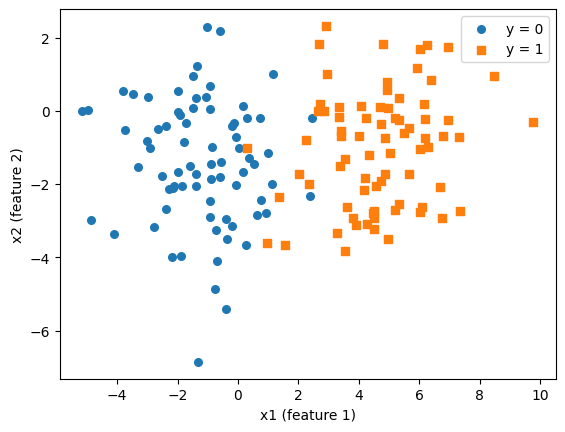

In [ ]:
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='tab:blue', s=30,
            label='y = 0', marker='o')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='tab:orange', s=30,
            label='y = 1', marker='s')

plt.xlabel('x1 (feature 1)')
plt.ylabel('x2 (feature 2)')
plt.legend(loc='best');

## 2.2. Separación en conjunto de entrenamiento y test.
Una práctica normal en la búsqueda de la $h(x)$ mas adecuada es la de dividir el conjunto en al menos dos partes que serán utilizadas para objetivos diferentes:
- Una parte será utilizada para ajustar el modelo (entrenamiento o train).
- Otra parte diferente será utilizada para medir que tan bueno es el modelo obtenido (validación o test).

Dividiremos el conjunto de datos en 75% y 25%. Para ello, utilizaremos la función `sklearn.model_selection`.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=311)

In [ ]:
X_train.shape

(112, 2)

In [ ]:
y_train.shape

(112,)

# 3. Utilización de un Modelo de Regresión Logística
Utilizaremos la clase `LogisticRegression` de sklearn con **los datos de entrenamiento**  para ajustar los parametros del modelo:

In [ ]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(C = 0.1)

Una vez creada la instancia del clasificador, debemos "entrenar" el modelo, es decir, ajustar sus parámetros.

In [ ]:
classifier.fit(X_train, y_train)

LogisticRegression(C=0.1)

El objeto `classifier` contiene el modelo ya entrenado. Sus parámetros son: $$ h(x) = \frac{1}{1 + e^{-(w_0 + w_1 x_1 + w_2 x_2)}}$$

In [ ]:
print('Vector de coeficientes de la función lineal: ', classifier.coef_)
print('Ordenada en el origen (W0): ', classifier.intercept_)

Vector de coeficientes de la función lineal:  [[1.11509305 0.08538909]]
Ordenada en el origen (W0):  [-1.58054767]


Vamos a observar como se comporta el modelo con los datos de entrenamiento.

Para ello, vamos a calcular la predicción para cada valor de $x$ de entrenamiento.

In [ ]:
y_pred_train = classifier.predict(X_train)

Podemos comparar los 20 primeros ejemplos de entrenamiento con el valor esperado:

In [ ]:
print('Etiquetas de train reales:    ', y_train[:18])
print('Etiquetas de train predichas: ', y_pred_train[:18])

Etiquetas de train reales:     [1 0 1 0 0 0 1 1 0 1 0 1 1 1 1 0 1 1]
Etiquetas de train predichas:  [1 0 1 0 0 0 1 1 0 1 0 1 1 1 1 0 1 0]


Como puede observarse, hay bastante parecido en este caso. Para tener una idea mejor del nivel de acierto, tenemos el método ```score```. En objetos para modelos de clasificación, este método nos devuelve el **accuracy**, que es la proporción de patrones correctamente clasificados.  

In [ ]:
classifier.score(X_train, y_train)

0.9732142857142857

Es decir, hay un acierto en la etiqueta correcta del 93,33%. Como podía esperarse, hay un nivel de acierto grande, pues estos fueron los datos desde los que se ajustaron los parámetros del modelo.

In [ ]:
np.mean(y_pred_train == y_train)

0.9732142857142857

Ahora veremos el desempeño en test, que es realmente la métrica que nos permite estimar el desempeño ante patrones nuevos, y por ello, del modelo general.

In [ ]:
y_pred_test = classifier.predict(X_test)

In [ ]:
print('Etiquetas de test reales:    ', y_test[:18])
print('Etiquetas de test predichas: ', y_pred_test[:18])

Etiquetas de test reales:     [0 0 0 0 0 0 1 0 1 0 1 1 0 1 0 1 0 0]
Etiquetas de test predichas:  [0 0 0 0 0 0 1 0 1 0 1 1 0 1 0 1 0 0]


In [ ]:
print('Accuracy en test: ', classifier.score(X_test, y_test))

Accuracy en test:  0.9210526315789473


Comparado con el accuracy en train es menor, lo cual es natural pues estos ejemplos no fueron tenidos en cuenta para ajustar el modelo.

Se pueden obtener, además de las predicciones, las probabilidades:

In [ ]:
probabilidades = classifier.predict_proba(X_test)

probabilidades[:10 ,:]

array([[0.86123355, 0.13876645],
       [0.98208629, 0.01791371],
       [0.88531003, 0.11468997],
       [0.98739668, 0.01260332],
       [0.55297061, 0.44702939],
       [0.92559379, 0.07440621],
       [0.09770924, 0.90229076],
       [0.83378983, 0.16621017],
       [0.04083435, 0.95916565],
       [0.68317566, 0.31682434]])

Podemos observar algunos gráficos del modelo.

In [ ]:
w0 = classifier.intercept_
w1 = classifier.coef_[0][0]
w2 = classifier.coef_[0][1]

a = -w1/w2
b = -w0/w2

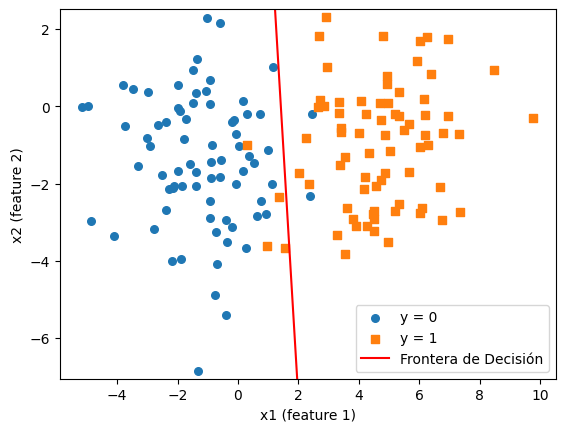

In [ ]:
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='tab:blue', s=30,
            label='y = 0', marker='o')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='tab:orange', s=30,
            label='y = 1', marker='s')
plt.plot([X[:,0].min(), X[:,0].max()], [a*X[:,0].min()+b, a*X[:,0].max()+b], c='red', label = 'Frontera de Decisión')
plt.xlabel('x1 (feature 1)')
plt.ylabel('x2 (feature 2)')
plt.ylim(top = X[:,1].max()+0.2, bottom = X[:,1].min()-0.2)
plt.legend(loc='best');

In [ ]:
%config InlineBackend.print_figure_kwargs = {'bbox_inches':None} # https://stackoverflow.com/questions/52636783/figsize-does-not-work-for-matplotlib-3d-plot

In [ ]:
import pandas as pd

x_1_surf = np.linspace(X[:,0].min(), X[:,0].max())
x_2_surf = np.linspace(X[:,1].min(), X[:,1].max())
x_1_surf, x_2_surf = np.meshgrid(x_1_surf, x_2_surf)
X_surface = pd.DataFrame({'x1': x_1_surf.ravel(), 'x2': x_2_surf.ravel()})
y_pred_surface_prob = classifier.predict_proba(X_surface)
y_pred_surface = y_pred_surface_prob[:, 1]

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


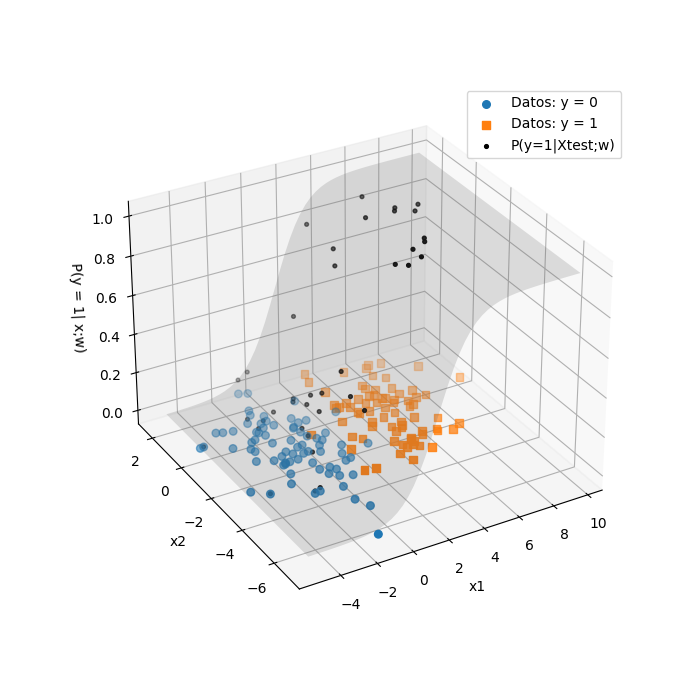

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(7, 7))
ax = plt.axes(projection = '3d')
ax.plot_surface(x_1_surf, x_2_surf, y_pred_surface.reshape(x_1_surf.shape),
                rstride=1000,
                cstride=1000,
                color='gray',
                alpha = 0.2)

ax.scatter(X[y == 0, 0], X[y == 0, 1], 0, c='tab:blue', s=30,
            label='Datos: y = 0', marker='o')
ax.scatter(X[y == 1, 0], X[y == 1, 1], 0, c='tab:orange', s=30,
            label='Datos: y = 1', marker='s')
ax.scatter(X_test[:,0], X_test[:,1], probabilidades[:,1], c='black', s=30,
            label='P(y=1|Xtest;w)', marker='.')
plt.xlabel('x1')
plt.ylabel('x2')
ax.set_zlabel('P(y = 1| x;w)')
ax.view_init(30, 240)


plt.legend(loc='best')
plt.show()

In [ ]:
from sklearn import metrics

confusion_matrix = metrics.confusion_matrix(y_test, y_pred_test)

matrix_df = pd.DataFrame(confusion_matrix)
matrix_df

,0,1
0,21,1
1,2,14


# 4. Utilización de un Clasificador Árbol de Decisión
Utilizaremos la clase `DecisionTreeClassifier` de sklearn con **los datos de entrenamiento**  para ajustar los parametros del modelo:

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
clf = DecisionTreeClassifier(max_depth=5)

In [ ]:
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [ ]:
clf.score(X_test, y_test)

0.9473684210526315

Grafiquemos los datos:

In [ ]:
x_1_surf = np.linspace(X[:,0].min(), X[:,0].max())
x_2_surf = np.linspace(X[:,1].min(), X[:,1].max())
x_1_surf, x_2_surf = np.meshgrid(x_1_surf, x_2_surf)
X_surface = pd.DataFrame({'x1': x_1_surf.ravel(), 'x2': x_2_surf.ravel()})

y_pred_surface = clf.predict_proba(X_surface)[:, 1].reshape(x_1_surf.shape)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


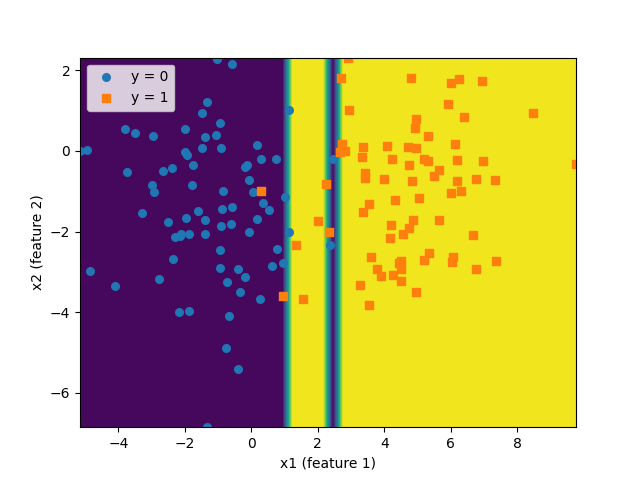

In [ ]:
plt.contourf(x_1_surf, x_2_surf, y_pred_surface, 25,
                      vmin=0, vmax=1)
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='tab:blue', s=30,
            label='y = 0', marker='o')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='tab:orange', s=30,
            label='y = 1', marker='s')
plt.xlabel('x1 (feature 1)')
plt.ylabel('x2 (feature 2)')
plt.legend(loc='best');

In [ ]:
from sklearn import tree

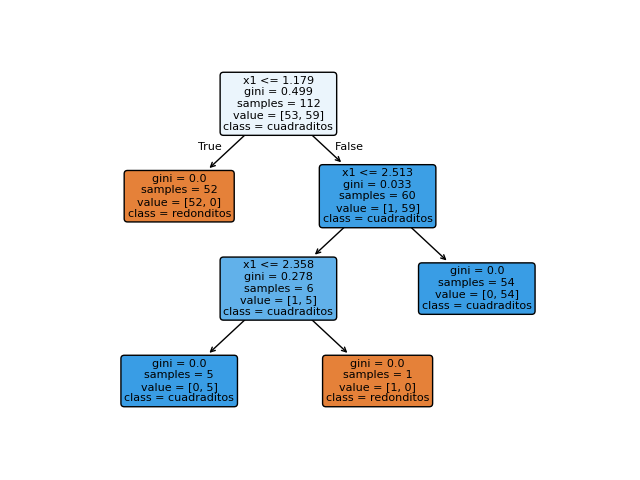

In [ ]:
labels = ['redonditos', 'cuadraditos']
feature_names = ['x1', 'x2']
a = tree.plot_tree(clf,
                   feature_names = feature_names,
                   class_names = labels,
                   rounded = True,
                   filled = True,
                   fontsize=8)
plt.show()



<div class="alert alert-warning">
    <b>Actividad</b>:
    <hr>
     <ul>
      <li>Aumentar la cantidad de muestras y ejecutar nuevamente toda la notebook.</li>
      <li>Modifica parámetros ambos modelos (C en regresión logística y max_depth en árbol de decisión) y observa el resultado en el accuracy en test.</li>
    <li>Revisar cambios en los resultados.</li>
    </ul>
</div>

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()

In [ ]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [ ]:
X_data = iris.data
target = iris.target
feature_names = iris.feature_names

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_data, target, test_size=0.25, random_state=311)

In [ ]:
clf = DecisionTreeClassifier(max_depth=5)

In [ ]:
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [ ]:
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)

In [ ]:
clf.score(X_train, y_train)

1.0

In [ ]:
clf.score(X_test, y_test)

0.8947368421052632

In [ ]:
from sklearn.tree import export_text

In [ ]:

tree_rules = export_text(clf, feature_names = list(feature_names))
print(tree_rules)

|--- petal length (cm) <= 2.50
|   |--- class: 0
|--- petal length (cm) >  2.50
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 5.05
|   |   |   |--- sepal length (cm) <= 4.95
|   |   |   |   |--- class: 2
|   |   |   |--- sepal length (cm) >  4.95
|   |   |   |   |--- class: 1
|   |   |--- petal length (cm) >  5.05
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- class: 2



In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
confusion_matrix = confusion_matrix(y_test, y_pred_test)
confusion_matrix

array([[11,  0,  0],
       [ 0, 10,  3],
       [ 0,  1, 13]])

In [ ]:
matrix_df = pd.DataFrame(confusion_matrix)
matrix_df

,0,1,2
0,11,0,0
1,0,10,3
2,0,1,13


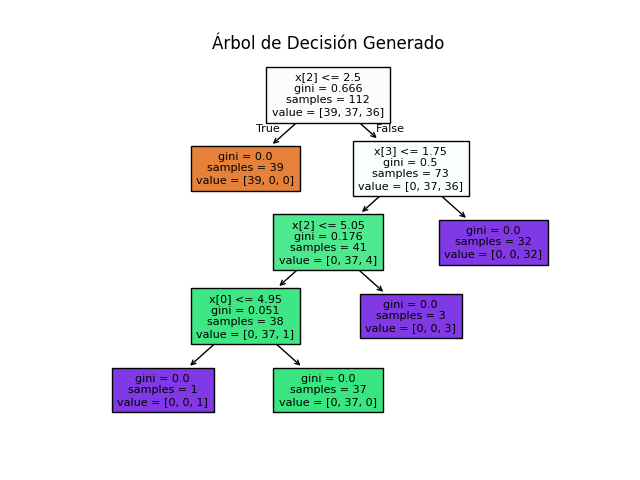

In [ ]:
from sklearn.tree import plot_tree

plt.figure()
plot_tree(clf, filled=True, fontsize = 8)
plt.title("Árbol de Decisión Generado")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics


In [ ]:
# Creamos el modelo
model = RandomForestClassifier(n_estimators=100, max_depth=5)

# Entrenamos el modelo
model.fit(X_train, y_train)

# Realizamos predicciones
y_pred = model.predict(X_test)

# Evaluamos el modelo
print(metrics.accuracy_score(y_test, y_pred))

0.9210526315789473
